In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pywt

In [3]:
IN_PATH  = "../../data/NF-UNSW-NB15-v3.csv"
label_col = 'Attack'
wavelet_name = 'cmor3.5-1.0'
max_examples = 200
scales = np.arange(1, 128)

In [4]:
#Load the data
df = pd.read_csv(IN_PATH)

In [5]:
attack_types = df['Attack'].unique()
sampled_dfs = []

In [6]:
for attack in attack_types:
    attack_df = df[df['Attack'] == attack]
    sample_size = min(len(attack_df), max_examples)
    sampled = attack_df.sample(n=sample_size, random_state=42)
    sampled_dfs.append(sampled)

In [7]:
sampled_df = pd.concat(sampled_dfs, ignore_index=True)
print("Sampled dataframe shape:", sampled_df.shape)
print(sampled_df['Attack'].value_counts())

Sampled dataframe shape: (1958, 55)
Attack
Benign            200
Fuzzers           200
Exploits          200
Backdoor          200
Reconnaissance    200
Generic           200
DoS               200
Shellcode         200
Analysis          200
Worms             158
Name: count, dtype: int64


In [9]:
numeric_cols = sampled_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS']
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

In [10]:
signal = sampled_df[numeric_cols].values.flatten()
print("Signal shape for CWT:", signal.shape)
print("Example values:", signal[:10])

Signal shape for CWT: (97900,)
Example values: [4.255e+03 5.300e+01 1.700e+01 5.000e+00 1.460e+02 2.000e+00 1.780e+02
 2.000e+00 0.000e+00 0.000e+00]


In [11]:
signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-12)

In [12]:
coefficients, frequencies = pywt.cwt(signal, scales, wavelet_name)

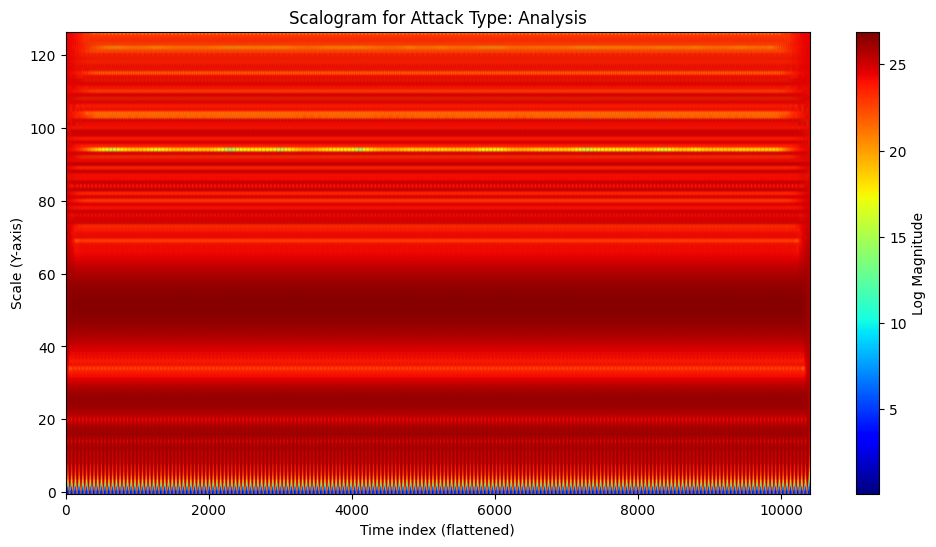

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


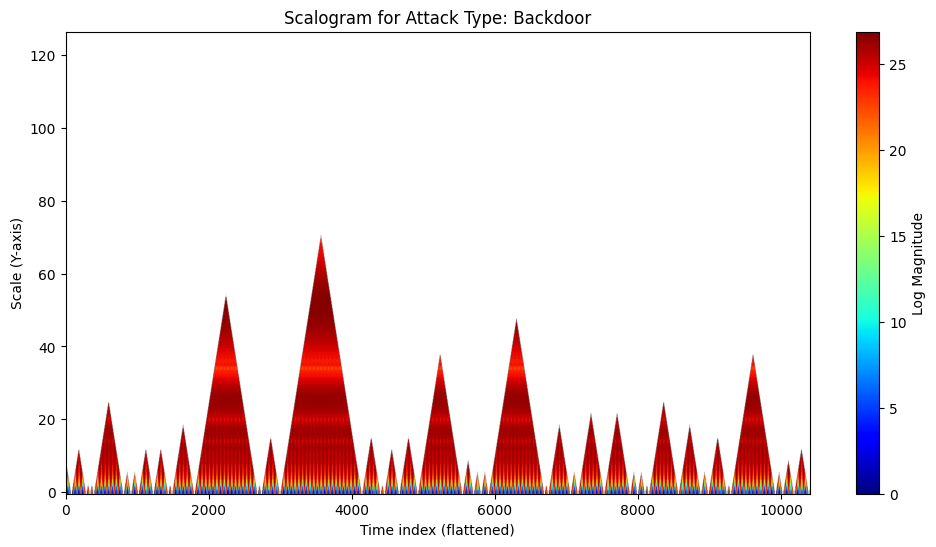

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\numpy\lib\_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


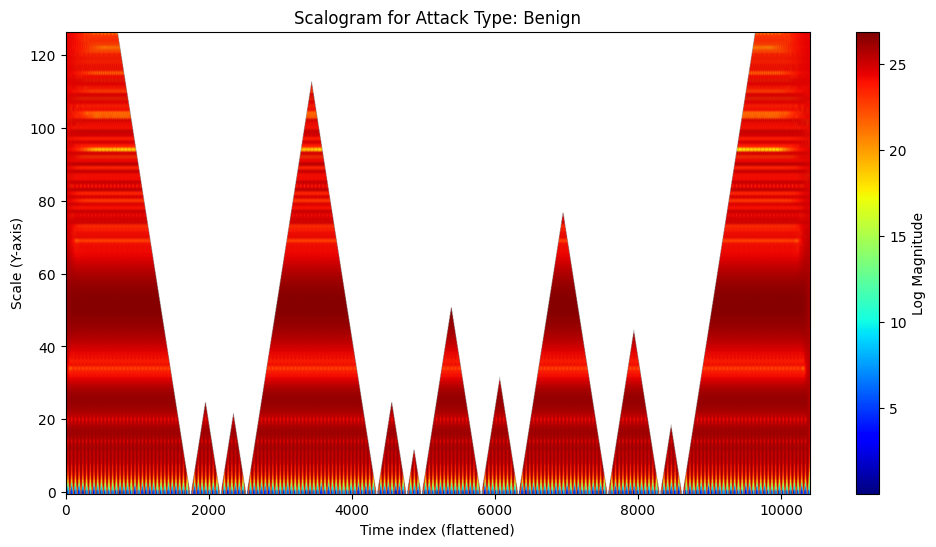

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


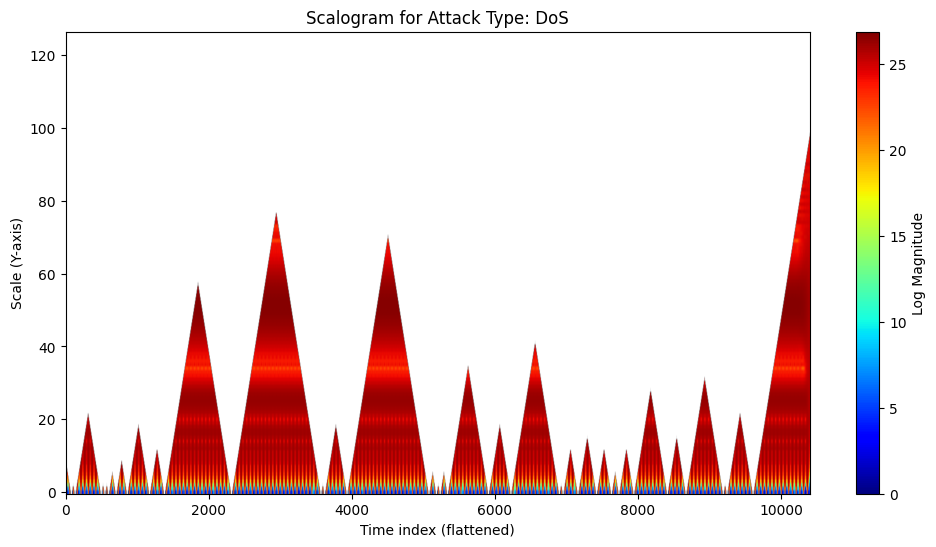

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


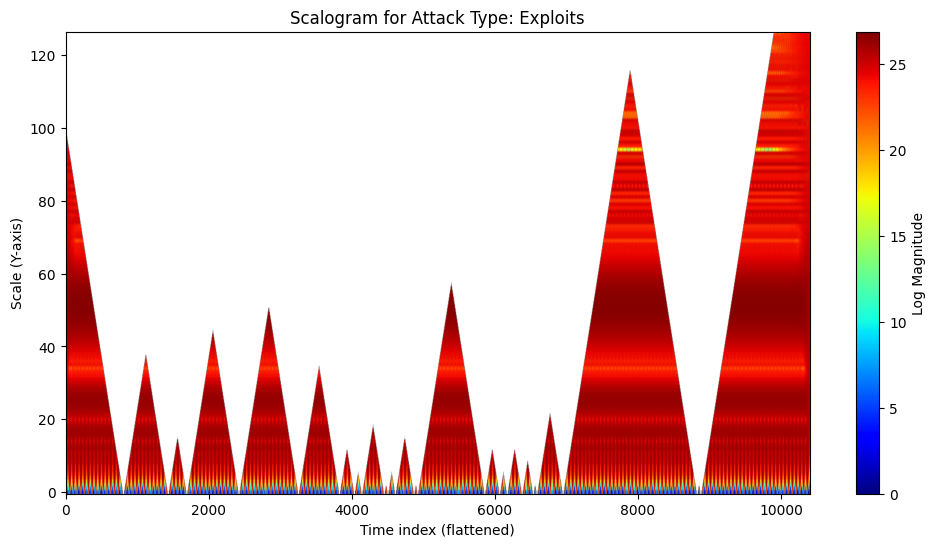

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


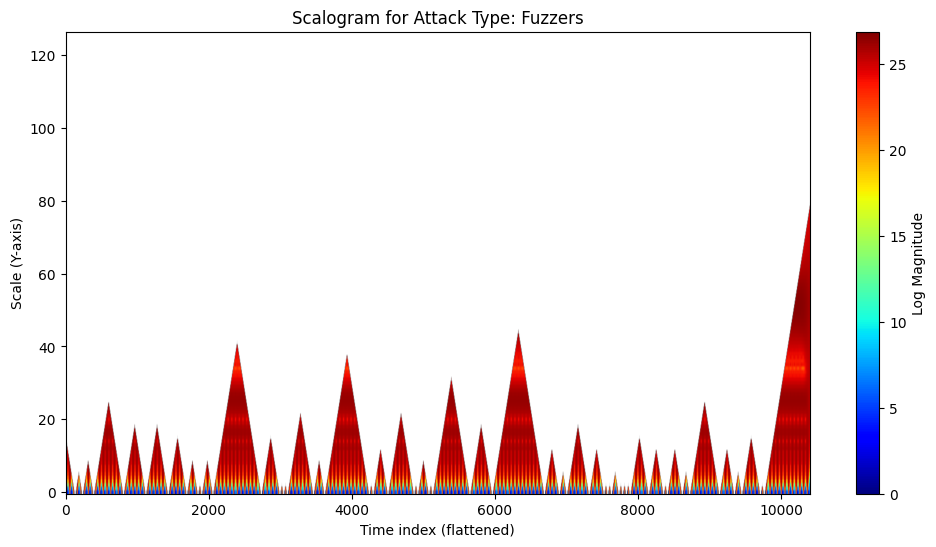

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


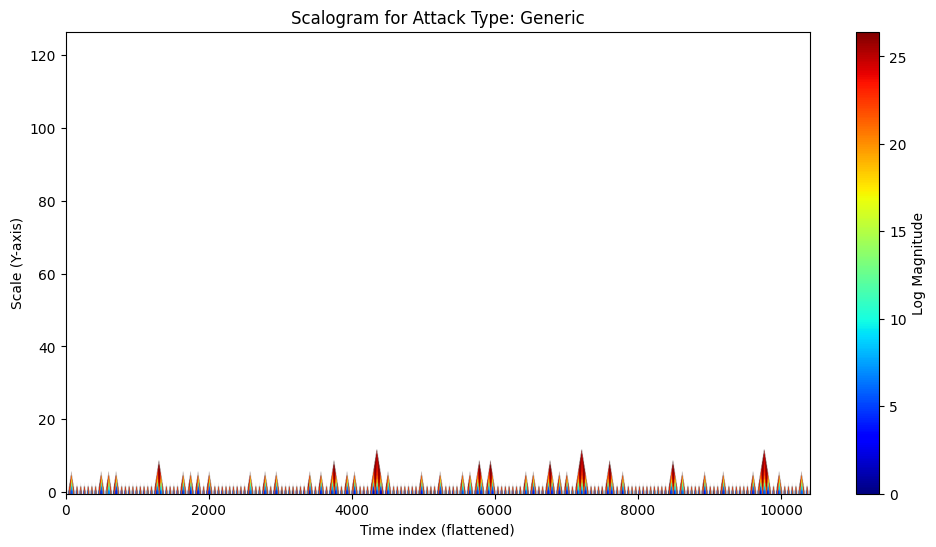

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


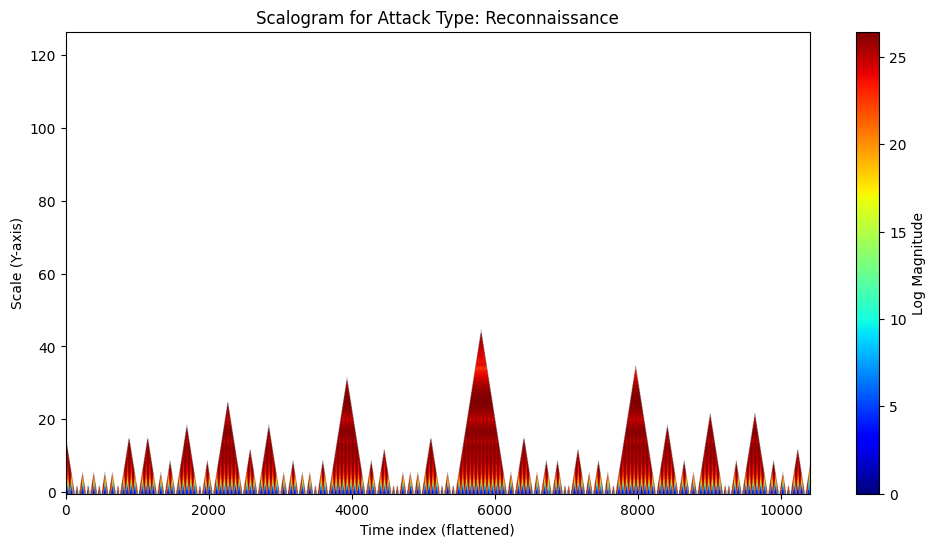

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


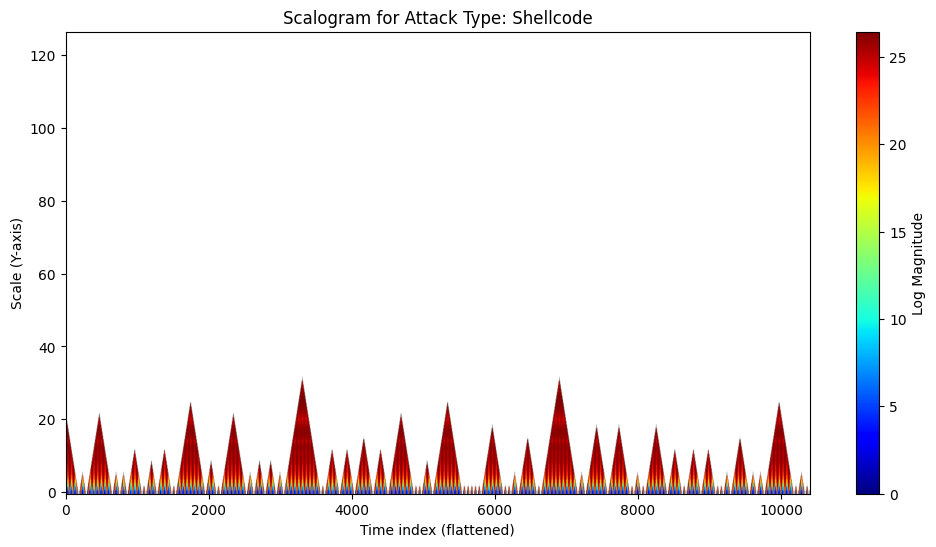

c:\Users\Lizzie\OneDrive\Documents\TF-ML-NIDS\venv\lib\site-packages\pywt\_cwt.py:186: RuntimeWarning: invalid value encountered in multiply
  coef = - np.sqrt(scale) * np.diff(conv, axis=-1)


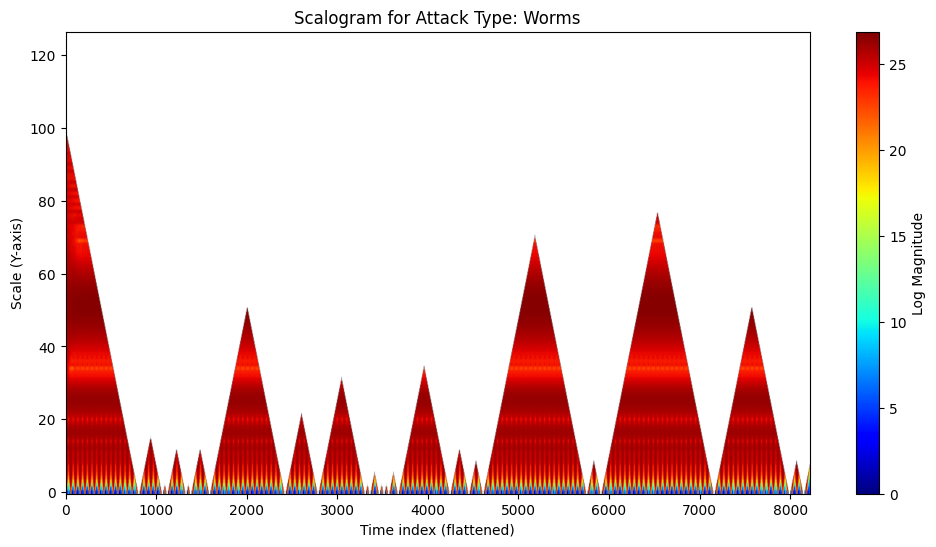

In [14]:
for attack_type, group in sampled_df.groupby('Attack'):
    numeric_cols = group.select_dtypes(include='number').columns
    signal = group[numeric_cols].values.flatten()
    
    coefficients, freqs = pywt.cwt(signal, scales, wavelet_name)
    magnitude = np.abs(coefficients)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(np.log1p(magnitude), aspect='auto', cmap='jet', origin='lower')
    plt.colorbar(label='Log Magnitude')
    plt.ylabel('Scale (Y-axis)')
    plt.xlabel('Time index (flattened)')
    plt.title(f'Scalogram for Attack Type: {attack_type}')
    plt.show()